In [1]:
import pandas as pd
import numpy as np



import sys
sys.path.append('..')

# Loading Data

In [2]:
pd.read_csv(f"../data_in_processing/E1S1_graphs_flattened.csv", index_col=[0, 1, 2]).head()

ERK_me_t0  ERK_neigh_t0  ERK_me_t1  \
Image_Metadata_T track_id_t0 track_id_t1                                       
0                1201        1495          0.713311      0.008047   0.577748   
                             874           0.713311      0.765061   0.577748   
                             304           0.713311      0.004324   0.577748   
                 1495        1201          0.008047      0.713311   0.002635   
                             304           0.008047      0.004324   0.002635   

                                          ERK_neigh_t1  ERK_me_diff  \
Image_Metadata_T track_id_t0 track_id_t1                              
0                1201        1495             0.002635    -0.135563   
                             874              0.802783    -0.135563   
                             304              0.020567    -0.135563   
                 1495        1201             0.577748    -0.005412   
                             304              0.020567    -0.005412   

                                          ERK_neigh_diff  
Image_Metadata_T track_id_t0 track_id_t1                  
0                1201        1495              -0.005412  
                             874                0.037722  
                             304                0.016243  
                 1495        1201              -0.135563  
                             304                0.016243

In [3]:
df = pd.read_csv(f"../data_in_processing/E1S1_graphs_flattened.csv", index_col=[0, 1, 2])

df = df["ERK_me_diff ERK_neigh_diff".split(" ")]

df.head(10)

ERK_me_diff  ERK_neigh_diff
Image_Metadata_T track_id_t0 track_id_t1                             
0                1201        1495           -0.135563       -0.005412
                             874            -0.135563        0.037722
                             304            -0.135563        0.016243
                 1495        1201           -0.005412       -0.135563
                             304            -0.005412        0.016243
                             199            -0.005412       -0.030668
                             1165           -0.005412        0.006947
                 874         1201            0.037722       -0.135563
                             304             0.037722        0.016243
                             1585            0.037722       -0.083374

# Viewing Data

In [4]:
import matplotlib.pyplot as plt

In [5]:
def plot_data(df: pd.DataFrame, labels: list[int]|None = None, alpha = 0.05) -> None:
    fig, ax = plt.subplots(1, figsize=(10, 10))

    if labels is None:
        ax.scatter(
            df[df.columns[0]].to_numpy(),
            df[df.columns[1]].to_numpy(),
            marker='.',
            alpha = alpha,
        )
    else:
        for lab_idx in labels:
            ax.scatter(
                df[df.columns[0]].to_numpy(),
                df[df.columns[1]].to_numpy(),
                marker='.',
                alpha = alpha,
                label = f"lab{lab_idx}",
            )

    ax.set_title("Data Visualized")

    ax.set_xlabel(df.columns[0])
    ax.set_xlabel(df.columns[1])

    ax.legend()

/tmp/ipykernel_20608/2060979094.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


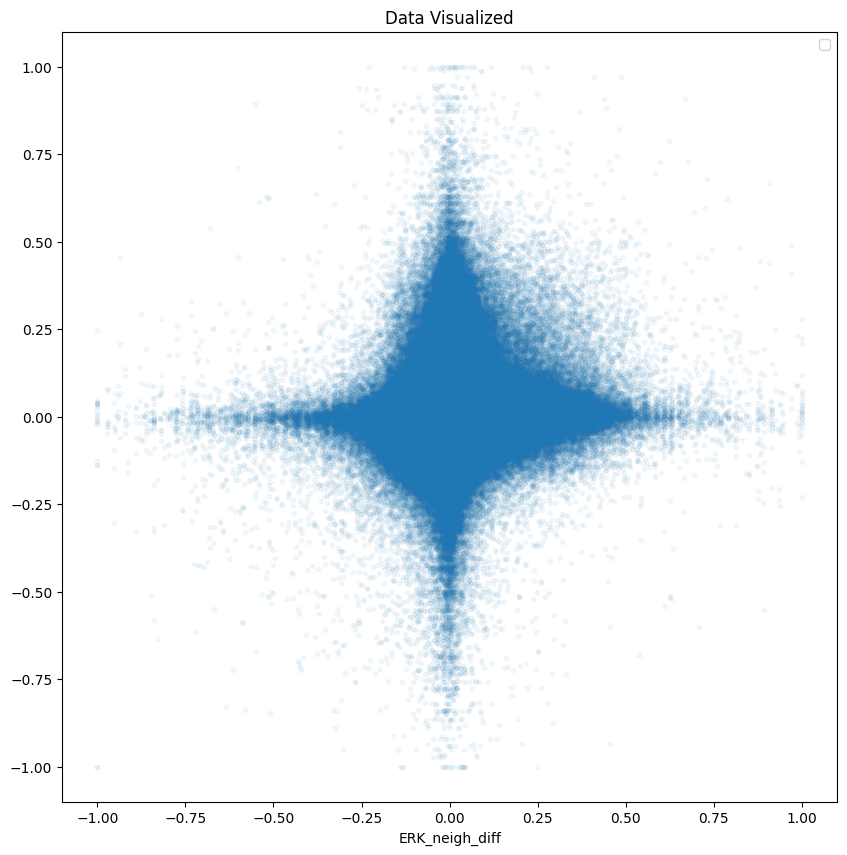

In [6]:
plot_data(df)

# Run Clustering

In [7]:
from sklearn.cluster import MeanShift, BisectingKMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage
import hdbscan

In [8]:
clus_id: int = 4

In [11]:
clusterer = AgglomerativeClustering(n_clusters=4, metric="chebyshev", linkage="single")

In [12]:
clusterer.fit(df.to_numpy())

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",4
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'chebyshev'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'single'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [13]:
df["label"] = clusterer.labels_

In [14]:
df.head(20)

ERK_me_diff  ERK_neigh_diff  label
Image_Metadata_T track_id_t0 track_id_t1                                    
0                1201        1495           -0.135563       -0.005412      0
                             874            -0.135563        0.037722      0
                             304            -0.135563        0.016243      0
                 1495        1201           -0.005412       -0.135563      0
                             304            -0.005412        0.016243      0
                             199            -0.005412       -0.030668      0
                             1165           -0.005412        0.006947      0
                 874         1201            0.037722       -0.135563      0
                             304             0.037722        0.016243      0
                             1585            0.037722       -0.083374      0
                             519             0.037722       -0.073068      0
                             190             0.037722        0.098540      0
                 304         1201            0.016243       -0.135563      0
                             1495            0.016243       -0.005412      0
                             874             0.016243        0.037722      0
                             692             0.016243        0.010082      0
                             519             0.016243       -0.073068      0
                             199             0.016243       -0.030668      0
                 211         817            -0.003564        0.004712      0
                             229            -0.003564        0.007475      0

# Cluster Statistics

In [15]:
from scripts.Scoring_clusters import clustering_coverage_stats, run_scoring

In [16]:
df["label"].value_counts()

label
0    2057640
1          2
3          1
2          1
Name: count, dtype: int64

In [17]:
len(df["label"].unique())

4

In [18]:
clustering_coverage_stats(df)


    Nodes with Labels:				2057644
    Nodes without Labels:			0
    Nodes ratio [with label / all]:		2057644 / 2057644
    Nodes ratio [with label / all][%]:		100.00%
    Noise [without label / all][%]:		0.00%
    


In [19]:
_ = run_scoring(df)

Davies-Bouldin Score:                   0.056
Calinski-Harabasz Score:                219.624


# Clustering Visualization

/home/karol/Pulpit/MIMUW/SystemBiology/Systems-Biology_project-2/venv/lib64/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/karol/Pulpit/MIMUW/SystemBiology/Systems-Biology_project-2/venv/lib64/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


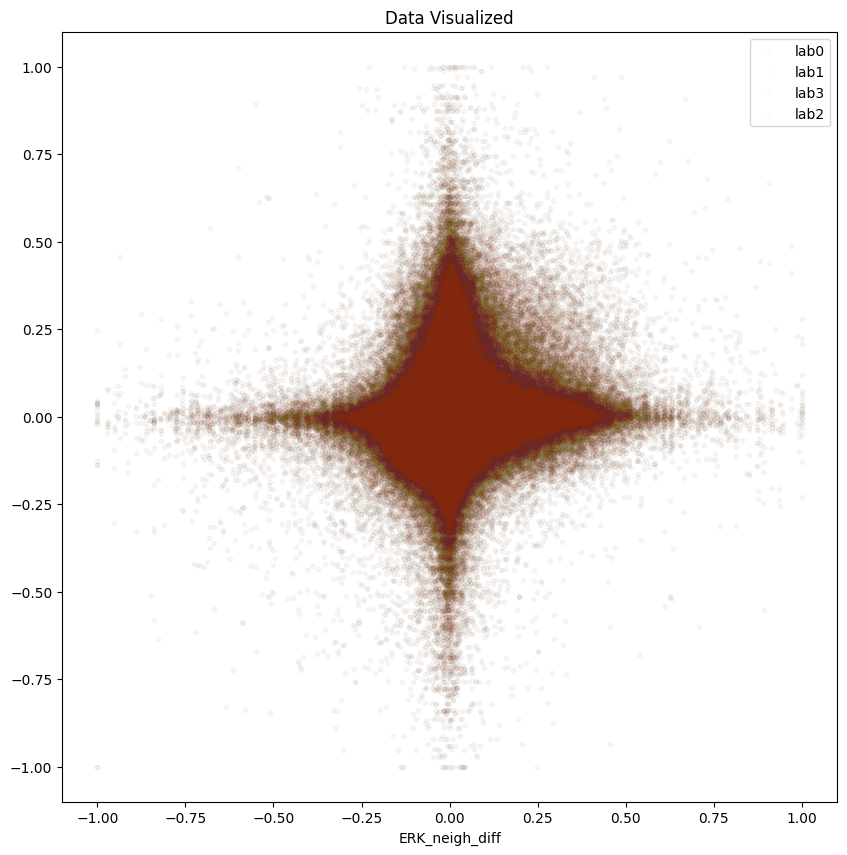

In [ ]:
plot_data(
    df, 
    labels=[lab_idx for i, lab_idx in df["label"].value_counts().to_dict().keys() if lab_idx not in {-1}],
    alpha = 0.01
)

# Viewing Stats about Labels

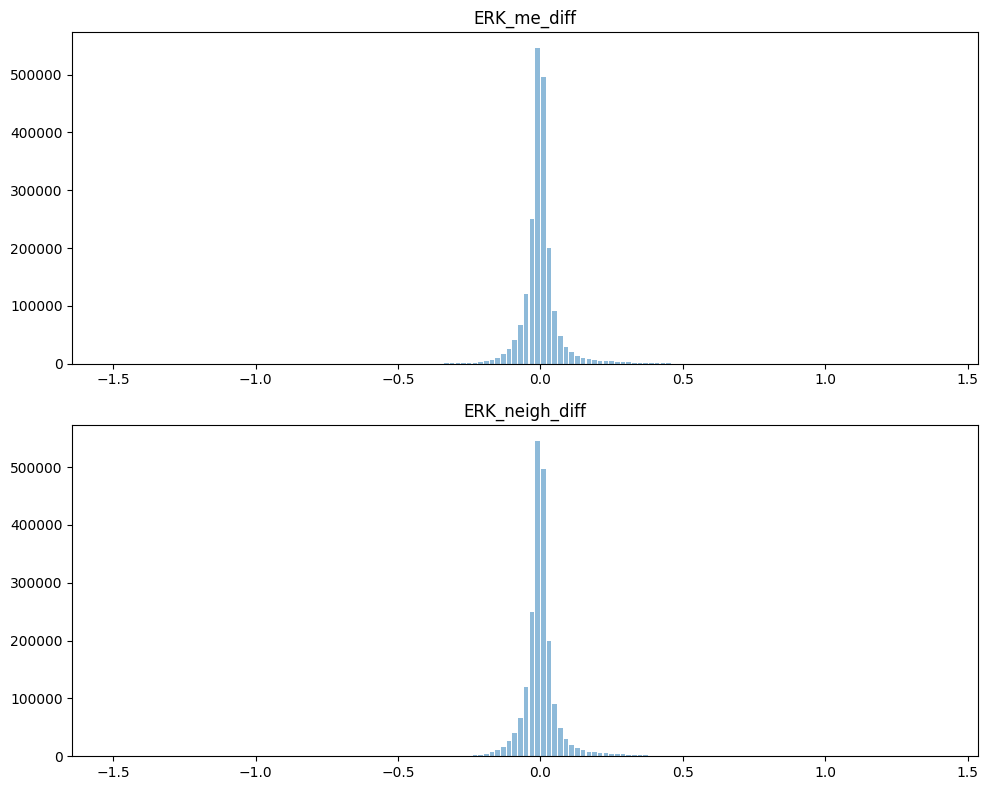

In [21]:
selected_columns = [col for col in df.columns if col not in {"label"}]

fig, axs = plt.subplots(len(selected_columns), figsize = (10, 8))

for i, col in enumerate(selected_columns):
    
    for lab_idx in df["label"].value_counts().to_dict().keys():
        axs[i].hist(df[df["label"] == lab_idx][col], rwidth = 0.8, bins = 100, alpha = 0.5, label = f"lab = {lab_idx}")
    axs[i].set_title(col)
    
fig.tight_layout()

# Saving Labels & Params

In [22]:
import pickle

In [23]:
df.drop(columns=[col for col in df.columns if col not in {"label"}]).to_csv(f"../data_in_processing/cluster_outputs/labels_{clus_id}.csv")

with open(f"../data_in_processing/cluster_outputs/params_{clus_id}.pickle", "wb") as params_f:
    pickle.dump(clusterer.get_params(), params_f)

In [24]:
df[df["label"].isin([2, 0, 3])]

ERK_me_diff  ERK_neigh_diff  label
Image_Metadata_T track_id_t0 track_id_t1                                    
0                1201        1495           -0.135563       -0.005412      0
                             874            -0.135563        0.037722      0
                             304            -0.135563        0.016243      0
                 1495        1201           -0.005412       -0.135563      0
                             304            -0.005412        0.016243      0
...                                               ...             ...    ...
256              749         778            -0.002142        0.143538      0
                             1042           -0.002142        0.168321      0
                             2207           -0.002142       -0.056219      0
                             134            -0.002142       -0.032461      0
                             1615           -0.002142       -0.071355      0

[2057642 rows x 3 columns]